# T-Learner Uplift Models

This notebook implements logistic-regression and XGBoost T-learners for the binary Hillstrom email treatment.

Each T-learner fits two separate outcome models:

- **Treatment model:** estimates the probability of a visit if a customer receives an email.
- **Control model:** estimates the probability of a visit if a customer receives no email.

Estimated uplift is:

$$
\hat{\tau}(X)
=
\hat{P}(Y=1 \mid X,T=1)
-
\hat{P}(Y=1 \mid X,T=0)
$$

The treatment combines the men's and women's email groups into one email-treatment group.

### Import required libraries

This cell imports the data-processing, modeling, visualization, and uplift-evaluation tools used throughout the notebook.

In [7]:
import sys
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
)
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from sklift.metrics import (
    qini_curve,
    qini_auc_score,
    uplift_curve,
    uplift_auc_score,
)

pd.set_option("display.max_columns", 100)
plt.style.use("seaborn-v0_8-darkgrid")

### Configure project paths

This cell locates the repository root, imports shared project settings, and ensures the T-learner output directories exist.

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    PROCESSED_DATA_DIR,
    PREDICTIONS_DIR,
    MODEL_RESULTS_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    RANDOM_STATE,
    PRIMARY_OUTCOME,
)

PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data:", PROCESSED_DATA_DIR)
print("Predictions output:", PREDICTIONS_DIR)
print("Results output:", MODEL_RESULTS_DIR)

Project root: /Users/chris/Documents/GitHub/hillstrom-email-uplift-modeling
Processed data: /Users/chris/Documents/GitHub/hillstrom-email-uplift-modeling/data/processed
Predictions output: /Users/chris/Documents/GitHub/hillstrom-email-uplift-modeling/outputs/predictions
Results output: /Users/chris/Documents/GitHub/hillstrom-email-uplift-modeling/outputs/model_results


### Load processed modeling data

This cell loads the shared feature matrices, visit outcomes, binary treatment indicators, and original campaign labels.

In [3]:
X_train = pd.read_csv(PROCESSED_DATA_DIR / "X_train.csv")
X_test = pd.read_csv(PROCESSED_DATA_DIR / "X_test.csv")

y_train = pd.read_csv(
    PROCESSED_DATA_DIR / "y_train.csv"
).squeeze("columns")

y_test = pd.read_csv(
    PROCESSED_DATA_DIR / "y_test.csv"
).squeeze("columns")

treatment_train = pd.read_csv(
    PROCESSED_DATA_DIR / "treatment_train.csv"
).squeeze("columns")

treatment_test = pd.read_csv(
    PROCESSED_DATA_DIR / "treatment_test.csv"
).squeeze("columns")

segment_test = pd.read_csv(
    PROCESSED_DATA_DIR / "segment_test.csv"
).squeeze("columns")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining treatment counts:")
print(treatment_train.value_counts().sort_index())

print("\nTesting treatment counts:")
print(treatment_test.value_counts().sort_index())

print("\nTraining visit rates:")
print(
    pd.DataFrame({
        "visit": y_train,
        "treatment": treatment_train
    })
    .groupby("treatment")["visit"]
    .mean()
)

X_train shape: (48000, 18)
X_test shape: (16000, 18)

Training treatment counts:
treatment_binary
0    15980
1    32020
Name: count, dtype: int64

Testing treatment counts:
treatment_binary
0     5326
1    10674
Name: count, dtype: int64

Training visit rates:
treatment
0    0.106195
1    0.167021
Name: visit, dtype: float64


### Validate the modeling data

This cell confirms that the feature, outcome, and treatment files have consistent dimensions and valid binary values.

In [4]:
assert list(X_train.columns) == list(X_test.columns)

assert len(X_train) == len(y_train) == len(treatment_train)
assert len(X_test) == len(y_test) == len(treatment_test)

assert set(y_train.unique()).issubset({0, 1})
assert set(y_test.unique()).issubset({0, 1})

assert set(treatment_train.unique()).issubset({0, 1})
assert set(treatment_test.unique()).issubset({0, 1})

assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

print("Data validation passed.")

Data validation passed.


### Separate treated and control observations

This cell creates the treatment and control training samples that both T-learners will use to fit their two outcome models.

In [5]:
train_treated_mask = treatment_train == 1
train_control_mask = treatment_train == 0

test_treated_mask = treatment_test == 1
test_control_mask = treatment_test == 0

X_train_treated = X_train.loc[train_treated_mask]
y_train_treated = y_train.loc[train_treated_mask]

X_train_control = X_train.loc[train_control_mask]
y_train_control = y_train.loc[train_control_mask]

print("Treated training observations:", len(X_train_treated))
print("Control training observations:", len(X_train_control))

print("\nTraining visit rates:")
print("Treated:", y_train_treated.mean())
print("Control:", y_train_control.mean())

assert y_train_treated.nunique() == 2
assert y_train_control.nunique() == 2

Treated training observations: 32020
Control training observations: 15980

Training visit rates:
Treated: 0.1670206121174266
Control: 0.10619524405506883


### Train the logistic-regression T-learner

This cell fits separate logistic-regression outcome models using the treated and control training observations.

In [6]:
lgr_treated_model = LogisticRegression(
    max_iter=2000,
    solver="lbfgs"
)

lgr_control_model = LogisticRegression(
    max_iter=2000,
    solver="lbfgs"
)

lgr_treated_model.fit(
    X_train_treated,
    y_train_treated
)

lgr_control_model.fit(
    X_train_control,
    y_train_control
)

print("Logistic-regression T-learner trained successfully.")

Logistic-regression T-learner trained successfully.


### Train the XGBoost T-learner

This cell fits separate XGBoost outcome models that can capture nonlinear customer patterns and feature interactions.

In [8]:
xgb_parameters = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "n_estimators": 200,
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

xgb_treated_model = xgb.XGBClassifier(
    **xgb_parameters
)

xgb_control_model = xgb.XGBClassifier(
    **xgb_parameters
)

xgb_treated_model.fit(
    X_train_treated,
    y_train_treated
)

xgb_control_model.fit(
    X_train_control,
    y_train_control
)

print("XGBoost T-learner trained successfully.")

XGBoost T-learner trained successfully.


### Train the Random Forest T-learner

This cell fits separate regularized random forests to estimate visit probabilities under treatment and control.

In [9]:
rf_parameters = {
    "n_estimators": 300,
    "criterion": "gini",
    "max_depth": 8,
    "min_samples_leaf": 50,
    "max_features": "sqrt",
    "bootstrap": True,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

rf_treated_model = RandomForestClassifier(
    **rf_parameters
)

rf_control_model = RandomForestClassifier(
    **rf_parameters
)

rf_treated_model.fit(
    X_train_treated,
    y_train_treated
)

rf_control_model.fit(
    X_train_control,
    y_train_control
)

print("Random Forest T-learner trained successfully.")

Random Forest T-learner trained successfully.


### Estimate uplift with logistic regression

This cell scores every test customer under both treatment conditions and subtracts the control probability from the treatment probability.

In [10]:
lgr_pred_visit_if_treated = (
    lgr_treated_model.predict_proba(X_test)[:, 1]
)

lgr_pred_visit_if_control = (
    lgr_control_model.predict_proba(X_test)[:, 1]
)

lgr_predicted_uplift = (
    lgr_pred_visit_if_treated
    - lgr_pred_visit_if_control
)

### Estimate uplift with XGBoost

This cell uses the two XGBoost outcome models to calculate an alternative uplift estimate for every test customer.

In [11]:
xgb_pred_visit_if_treated = (
    xgb_treated_model.predict_proba(X_test)[:, 1]
)

xgb_pred_visit_if_control = (
    xgb_control_model.predict_proba(X_test)[:, 1]
)

xgb_predicted_uplift = (
    xgb_pred_visit_if_treated
    - xgb_pred_visit_if_control
)

### Estimate uplift with Random Forest

This cell calculates treatment and control visit probabilities from the two forests and subtracts them to estimate uplift.

In [12]:
rf_pred_visit_if_treated = (
    rf_treated_model.predict_proba(X_test)[:, 1]
)

rf_pred_visit_if_control = (
    rf_control_model.predict_proba(X_test)[:, 1]
)

rf_predicted_uplift = (
    rf_pred_visit_if_treated
    - rf_pred_visit_if_control
)

### Calculate the observed test-set ATE

This cell calculates the randomized test-set difference in visit rates between customers who received an email and those who did not.

In [13]:
observed_test_ate = (
    y_test.loc[test_treated_mask].mean()
    - y_test.loc[test_control_mask].mean()
)

print(f"Observed test-set ATE: {observed_test_ate:.4f}")

Observed test-set ATE: 0.0611


### Summarize logistic-regression uplift

This cell compares the logistic model's average predicted uplift with the observed ATE and reports its predicted-uplift range.

In [14]:
lgr_average_predicted_uplift = (
    lgr_predicted_uplift.mean()
)

lgr_minimum_predicted_uplift = (
    lgr_predicted_uplift.min()
)

lgr_maximum_predicted_uplift = (
    lgr_predicted_uplift.max()
)

print("Logistic-Regression T-Learner")
print("=" * 45)
print(f"Observed test-set ATE:       {observed_test_ate:.4f}")
print(f"Average predicted uplift:   {lgr_average_predicted_uplift:.4f}")
print(f"Minimum predicted uplift:   {lgr_minimum_predicted_uplift:.4f}")
print(f"Maximum predicted uplift:   {lgr_maximum_predicted_uplift:.4f}")

Logistic-Regression T-Learner
Observed test-set ATE:       0.0611
Average predicted uplift:   0.0598
Minimum predicted uplift:   -0.0385
Maximum predicted uplift:   0.1215


### Summarize XGBoost uplift

This cell compares the XGBoost model's average predicted uplift with the same observed ATE and reports its predicted-uplift range.

In [15]:
xgb_average_predicted_uplift = (
    xgb_predicted_uplift.mean()
)

xgb_minimum_predicted_uplift = (
    xgb_predicted_uplift.min()
)

xgb_maximum_predicted_uplift = (
    xgb_predicted_uplift.max()
)

print("XGBoost T-Learner")
print("=" * 45)
print(f"Observed test-set ATE:       {observed_test_ate:.4f}")
print(f"Average predicted uplift:   {xgb_average_predicted_uplift:.4f}")
print(f"Minimum predicted uplift:   {xgb_minimum_predicted_uplift:.4f}")
print(f"Maximum predicted uplift:   {xgb_maximum_predicted_uplift:.4f}")

XGBoost T-Learner
Observed test-set ATE:       0.0611
Average predicted uplift:   0.0601
Minimum predicted uplift:   -0.1633
Maximum predicted uplift:   0.2813


### Summarize Random Forest uplift

This cell compares the Random Forest's average predicted uplift with the observed ATE and displays its predicted range.

In [16]:
rf_average_predicted_uplift = (
    rf_predicted_uplift.mean()
)

rf_minimum_predicted_uplift = (
    rf_predicted_uplift.min()
)

rf_maximum_predicted_uplift = (
    rf_predicted_uplift.max()
)

print("Random Forest T-Learner")
print("=" * 45)
print(f"Observed test-set ATE:       {observed_test_ate:.4f}")
print(f"Average predicted uplift:   {rf_average_predicted_uplift:.4f}")
print(f"Minimum predicted uplift:   {rf_minimum_predicted_uplift:.4f}")
print(f"Maximum predicted uplift:   {rf_maximum_predicted_uplift:.4f}")

Random Forest T-Learner
Observed test-set ATE:       0.0611
Average predicted uplift:   0.0599
Minimum predicted uplift:   -0.0293
Maximum predicted uplift:   0.1625


### Evaluate logistic-regression outcome models

This cell evaluates each logistic outcome model only on test customers whose corresponding treatment condition was actually observed.

In [17]:
lgr_treated_auc = roc_auc_score(
    y_test.loc[test_treated_mask],
    lgr_pred_visit_if_treated[test_treated_mask]
)

lgr_control_auc = roc_auc_score(
    y_test.loc[test_control_mask],
    lgr_pred_visit_if_control[test_control_mask]
)

lgr_treated_brier = brier_score_loss(
    y_test.loc[test_treated_mask],
    lgr_pred_visit_if_treated[test_treated_mask]
)

lgr_control_brier = brier_score_loss(
    y_test.loc[test_control_mask],
    lgr_pred_visit_if_control[test_control_mask]
)

print("Logistic-Regression Factual Performance")
print("=" * 45)
print(f"Treatment-model ROC AUC: {lgr_treated_auc:.4f}")
print(f"Control-model ROC AUC:   {lgr_control_auc:.4f}")
print(f"Treatment-model Brier:   {lgr_treated_brier:.4f}")
print(f"Control-model Brier:     {lgr_control_brier:.4f}")

Logistic-Regression Factual Performance
Treatment-model ROC AUC: 0.6231
Control-model ROC AUC:   0.6376
Treatment-model Brier:   0.1356
Control-model Brier:     0.0932


### Evaluate XGBoost outcome models

This cell evaluates the XGBoost treatment model on treated customers and the XGBoost control model on control customers.

In [18]:
xgb_treated_auc = roc_auc_score(
    y_test.loc[test_treated_mask],
    xgb_pred_visit_if_treated[test_treated_mask]
)

xgb_control_auc = roc_auc_score(
    y_test.loc[test_control_mask],
    xgb_pred_visit_if_control[test_control_mask]
)

xgb_treated_brier = brier_score_loss(
    y_test.loc[test_treated_mask],
    xgb_pred_visit_if_treated[test_treated_mask]
)

xgb_control_brier = brier_score_loss(
    y_test.loc[test_control_mask],
    xgb_pred_visit_if_control[test_control_mask]
)

print("XGBoost Factual Performance")
print("=" * 45)
print(f"Treatment-model ROC AUC: {xgb_treated_auc:.4f}")
print(f"Control-model ROC AUC:   {xgb_control_auc:.4f}")
print(f"Treatment-model Brier:   {xgb_treated_brier:.4f}")
print(f"Control-model Brier:     {xgb_control_brier:.4f}")

XGBoost Factual Performance
Treatment-model ROC AUC: 0.6199
Control-model ROC AUC:   0.6193
Treatment-model Brier:   0.1357
Control-model Brier:     0.0940


### Evaluate Random Forest outcome models

This cell evaluates the Random Forest treatment model on treated customers and the control model on control customers.

In [19]:
rf_treated_auc = roc_auc_score(
    y_test.loc[test_treated_mask],
    rf_pred_visit_if_treated[test_treated_mask]
)

rf_control_auc = roc_auc_score(
    y_test.loc[test_control_mask],
    rf_pred_visit_if_control[test_control_mask]
)

rf_treated_brier = brier_score_loss(
    y_test.loc[test_treated_mask],
    rf_pred_visit_if_treated[test_treated_mask]
)

rf_control_brier = brier_score_loss(
    y_test.loc[test_control_mask],
    rf_pred_visit_if_control[test_control_mask]
)

print("Random Forest Factual Performance")
print("=" * 45)
print(f"Treatment-model ROC AUC: {rf_treated_auc:.4f}")
print(f"Control-model ROC AUC:   {rf_control_auc:.4f}")
print(f"Treatment-model Brier:   {rf_treated_brier:.4f}")
print(f"Control-model Brier:     {rf_control_brier:.4f}")

Random Forest Factual Performance
Treatment-model ROC AUC: 0.6185
Control-model ROC AUC:   0.6147
Treatment-model Brier:   0.1359
Control-model Brier:     0.0935


### Compare factual classification performance

This cell displays the ROC AUC and Brier scores for all treatment-specific outcome models.

In [20]:
factual_comparison = pd.DataFrame({
    "Model": [
        "Logistic treatment model",
        "Logistic control model",
        "XGBoost treatment model",
        "XGBoost control model",
        "Random Forest treatment model",
        "Random Forest control model",
    ],
    "ROC AUC": [
        lgr_treated_auc,
        lgr_control_auc,
        xgb_treated_auc,
        xgb_control_auc,
        rf_treated_auc,
        rf_control_auc,
    ],
    "Brier Score": [
        lgr_treated_brier,
        lgr_control_brier,
        xgb_treated_brier,
        xgb_control_brier,
        rf_treated_brier,
        rf_control_brier,
    ],
})

display(factual_comparison)

,Model,ROC AUC,Brier Score
0,Logistic treatment model,0.623065,0.135648
1,Logistic control model,0.637561,0.093215
2,XGBoost treatment model,0.619931,0.135698
3,XGBoost control model,0.619290,0.093969
4,Random Forest treatment model,0.618527,0.135852
5,Random Forest control model,0.614728,0.093453


### Combine model predictions

This cell places the observed outcomes, treatment labels, potential-outcome predictions, and uplift estimates from all models into one comparison dataset.

In [21]:
model_comparison_df = pd.DataFrame({
    "y_true": y_test.to_numpy(),
    "treatment": treatment_test.to_numpy(),
    "segment": segment_test.to_numpy(),
    "lgr_pred_visit_if_treated": lgr_pred_visit_if_treated,
    "lgr_pred_visit_if_control": lgr_pred_visit_if_control,
    "lgr_predicted_uplift": lgr_predicted_uplift,
    "xgb_pred_visit_if_treated": xgb_pred_visit_if_treated,
    "xgb_pred_visit_if_control": xgb_pred_visit_if_control,
    "xgb_predicted_uplift": xgb_predicted_uplift,
    "rf_pred_visit_if_treated": rf_pred_visit_if_treated,
    "rf_pred_visit_if_control": rf_pred_visit_if_control,
    "rf_predicted_uplift": rf_predicted_uplift,
})

display(model_comparison_df.head(10))

,y_true,treatment,segment,lgr_pred_visit_if_treated,lgr_pred_visit_if_control,lgr_predicted_uplift,xgb_pred_visit_if_treated,xgb_pred_visit_if_control,xgb_predicted_uplift,rf_pred_visit_if_treated,rf_pred_visit_if_control,rf_predicted_uplift
0,0,0,No E-Mail,0.100280,0.053483,0.046797,0.103082,0.054672,0.048410,0.102537,0.048884,0.053653
1,0,1,Womens E-Mail,0.210531,0.200071,0.010460,0.220238,0.157058,0.063180,0.209319,0.170513,0.038806
2,0,1,Mens E-Mail,0.142879,0.092592,0.050287,0.142801,0.111925,0.030876,0.153311,0.119666,0.033645
3,1,0,No E-Mail,0.160354,0.109339,0.051015,0.130331,0.122121,0.008211,0.141297,0.123809,0.017488
4,1,1,Mens E-Mail,0.192372,0.172869,0.019503,0.196546,0.153820,0.042725,0.198604,0.162747,0.035857
5,0,1,Mens E-Mail,0.310537,0.242432,0.068105,0.318156,0.191939,0.126217,0.240405,0.146415,0.093991
6,0,1,Womens E-Mail,0.207247,0.162898,0.044349,0.230904,0.178982,0.051922,0.221336,0.192958,0.028378
7,1,0,No E-Mail,0.099612,0.063537,0.036075,0.098333,0.075300,0.023033,0.113658,0.091217,0.022441
8,0,0,No E-Mail,0.179119,0.088445,0.090674,0.170188,0.087391,0.082797,0.183015,0.090346,0.092669
9,0,0,No E-Mail,0.234104,0.193412,0.040692,0.251746,0.126761,0.124986,0.216767,0.177681,0.039086


### Compare predicted-uplift distributions

This cell compares how widely logistic regression and XGBoost distribute their customer-level uplift estimates.

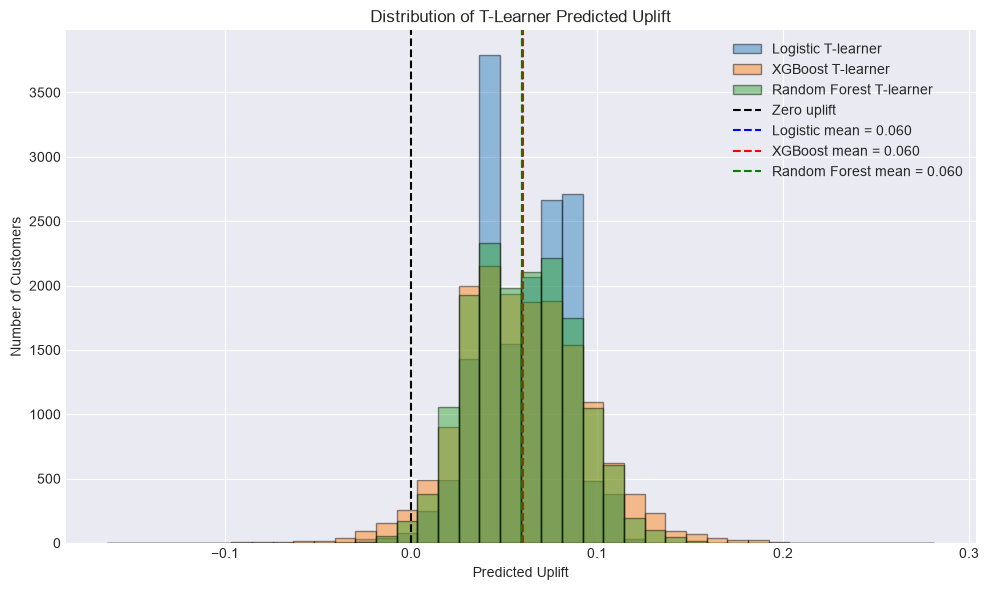

In [22]:
uplift_minimum = min(
    lgr_predicted_uplift.min(),
    xgb_predicted_uplift.min(),
    rf_predicted_uplift.min()
)

uplift_maximum = max(
    lgr_predicted_uplift.max(),
    xgb_predicted_uplift.max(),
    rf_predicted_uplift.max()
)

shared_bins = np.linspace(
    uplift_minimum,
    uplift_maximum,
    41
)

plt.figure(figsize=(10, 6))

plt.hist(
    lgr_predicted_uplift,
    bins=shared_bins,
    alpha=0.45,
    edgecolor="black",
    label="Logistic T-learner"
)

plt.hist(
    xgb_predicted_uplift,
    bins=shared_bins,
    alpha=0.45,
    edgecolor="black",
    label="XGBoost T-learner"
)

plt.hist(
    rf_predicted_uplift,
    bins=shared_bins,
    alpha=0.45,
    edgecolor="black",
    label="Random Forest T-learner"
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    label="Zero uplift"
)

plt.axvline(
    lgr_average_predicted_uplift,
    color="blue",
    linestyle="--",
    label=f"Logistic mean = {lgr_average_predicted_uplift:.3f}"
)

plt.axvline(
    xgb_average_predicted_uplift,
    color="red",
    linestyle="--",
    label=f"XGBoost mean = {xgb_average_predicted_uplift:.3f}"
)

plt.axvline(
    rf_average_predicted_uplift,
    color="green",
    linestyle="--",
    label=f"Random Forest mean = {rf_average_predicted_uplift:.3f}"
)

plt.xlabel("Predicted Uplift")
plt.ylabel("Number of Customers")
plt.title("Distribution of T-Learner Predicted Uplift")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "t_learner_uplift_distributions.png",
    dpi=150
)

plt.show()

### Define uplift-by-decile evaluation

This function ranks customers from highest to lowest predicted uplift and calculates observed treatment-control lift within each equally sized decile.

In [23]:
def calculate_uplift_by_decile(
    y_true,
    treatment,
    predicted_uplift,
    number_of_deciles=10
):
    decile_data = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "treatment": np.asarray(treatment),
        "predicted_uplift": np.asarray(predicted_uplift),
    })

    decile_data = (
        decile_data
        .sort_values(
            "predicted_uplift",
            ascending=False
        )
        .reset_index(drop=True)
    )

    decile_data["decile"] = pd.qcut(
        np.arange(len(decile_data)),
        q=number_of_deciles,
        labels=range(1, number_of_deciles + 1)
    ).astype(int)

    decile_results = []

    for decile, group in decile_data.groupby(
        "decile",
        sort=True
    ):
        treated_group = group[
            group["treatment"] == 1
        ]

        control_group = group[
            group["treatment"] == 0
        ]

        treated_visit_rate = (
            treated_group["y_true"].mean()
        )

        control_visit_rate = (
            control_group["y_true"].mean()
        )

        decile_results.append({
            "decile": int(decile),
            "customers": int(len(group)),
            "mean_predicted_uplift": (
                group["predicted_uplift"].mean()
            ),
            "treated_customers": int(len(treated_group)),
            "control_customers": int(len(control_group)),
            "treated_visit_rate": treated_visit_rate,
            "control_visit_rate": control_visit_rate,
            "observed_uplift": (
                treated_visit_rate
                - control_visit_rate
            ),
        })

    return pd.DataFrame(decile_results)

### Calculate model uplift by decile

This cell applies the same decile-ranking procedure to the logistic-regression and XGBoost uplift predictions.

In [24]:
lgr_decile_results = calculate_uplift_by_decile(
    y_true=y_test,
    treatment=treatment_test,
    predicted_uplift=lgr_predicted_uplift
)

xgb_decile_results = calculate_uplift_by_decile(
    y_true=y_test,
    treatment=treatment_test,
    predicted_uplift=xgb_predicted_uplift
)

rf_decile_results = calculate_uplift_by_decile(
    y_true=y_test,
    treatment=treatment_test,
    predicted_uplift=rf_predicted_uplift
)


print("Logistic-regression deciles:")
display(lgr_decile_results)

print("XGBoost deciles:")
display(xgb_decile_results)

print("Random Forest deciles:")
display(rf_decile_results)

Logistic-regression deciles:


,decile,customers,mean_predicted_uplift,treated_customers,control_customers,treated_visit_rate,control_visit_rate,observed_uplift
0,1,1600,0.096317,1024,576,0.245117,0.126736,0.118381
1,2,1600,0.084653,1042,558,0.218810,0.143369,0.075441
2,3,1600,0.079194,1112,488,0.174460,0.118852,0.055608
3,4,1600,0.072374,1076,524,0.162639,0.085878,0.076762
4,5,1600,0.066452,1079,521,0.164041,0.095969,0.068071
5,6,1600,0.053762,1040,560,0.125000,0.076786,0.048214
6,7,1600,0.046037,1081,519,0.139685,0.100193,0.039493
7,8,1600,0.042286,1075,525,0.114419,0.072381,0.042038
8,9,1600,0.037045,1077,523,0.139276,0.065010,0.074266
9,10,1600,0.020285,1068,532,0.191948,0.172932,0.019015


XGBoost deciles:


,decile,customers,mean_predicted_uplift,treated_customers,control_customers,treated_visit_rate,control_visit_rate,observed_uplift
0,1,1600,0.123540,1054,546,0.227704,0.163004,0.064700
1,2,1600,0.094510,1058,542,0.200378,0.103321,0.097057
2,3,1600,0.082385,1075,525,0.189767,0.125714,0.064053
3,4,1600,0.072475,1069,531,0.148737,0.084746,0.063991
4,5,1600,0.063403,1069,531,0.148737,0.101695,0.047042
5,6,1600,0.053589,1072,528,0.166978,0.121212,0.045765
6,7,1600,0.045076,1062,538,0.141243,0.079926,0.061317
7,8,1600,0.036873,1089,511,0.132231,0.072407,0.059824
8,9,1600,0.027971,1077,523,0.146704,0.084130,0.062574
9,10,1600,0.001348,1049,551,0.170639,0.121597,0.049042


Random Forest deciles:


,decile,customers,mean_predicted_uplift,treated_customers,control_customers,treated_visit_rate,control_visit_rate,observed_uplift
0,1,1600,0.109206,1052,548,0.223384,0.164234,0.059150
1,2,1600,0.089670,1069,531,0.186155,0.099812,0.086344
2,3,1600,0.080126,1068,532,0.177903,0.084586,0.093316
3,4,1600,0.072019,1050,550,0.169524,0.105455,0.064069
4,5,1600,0.063713,1076,524,0.178439,0.101145,0.077294
5,6,1600,0.054799,1068,532,0.157303,0.127820,0.029484
6,7,1600,0.046146,1045,555,0.151196,0.095495,0.055701
7,8,1600,0.038621,1081,519,0.138760,0.084778,0.053982
8,9,1600,0.030129,1110,490,0.129730,0.091837,0.037893
9,10,1600,0.014378,1055,545,0.161137,0.102752,0.058385


### Plot observed uplift by predicted-uplift decile

This chart tests whether customers ranked in the highest predicted-uplift deciles demonstrate stronger observed treatment-control lift. 1= Highest predicted, 10= lowest predicted

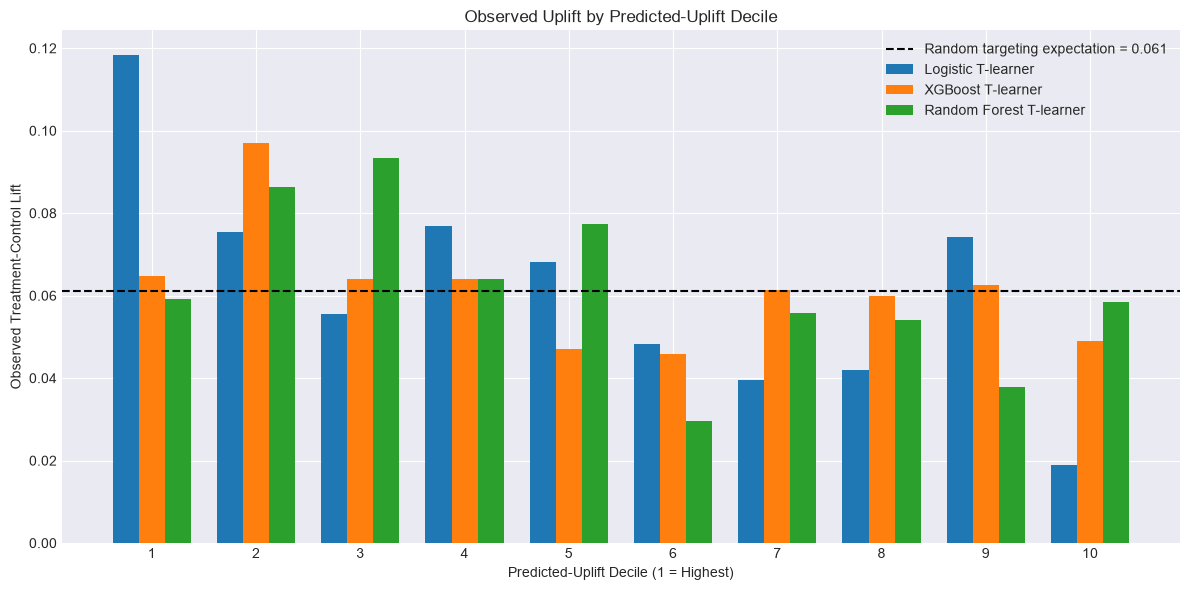

In [32]:
deciles = np.arange(1, 11)
bar_width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    deciles - bar_width,
    lgr_decile_results["observed_uplift"],
    width=bar_width,
    label="Logistic T-learner"
)

plt.bar(
    deciles,
    xgb_decile_results["observed_uplift"],
    width=bar_width,
    label="XGBoost T-learner"
)

plt.bar(
    deciles + bar_width,
    rf_decile_results["observed_uplift"],
    width=bar_width,
    label="Random Forest T-learner"
)

plt.axhline(
    observed_test_ate,
    color="black",
    linestyle="--",
    label=f"Random targeting expectation = {observed_test_ate:.3f}"
)

plt.xlabel("Predicted-Uplift Decile (1 = Highest)")
plt.ylabel("Observed Treatment-Control Lift")
plt.title("Observed Uplift by Predicted-Uplift Decile")
plt.xticks(deciles)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "t_learner_uplift_by_decile.png",
    dpi=150
)

plt.show()

### Calculate Qini performance

This cell measures how quickly each model accumulates incremental visits as progressively more customers are targeted.

In [26]:
lgr_qini_x, lgr_qini_y = qini_curve(
    y_true=y_test,
    uplift=lgr_predicted_uplift,
    treatment=treatment_test
)

xgb_qini_x, xgb_qini_y = qini_curve(
    y_true=y_test,
    uplift=xgb_predicted_uplift,
    treatment=treatment_test
)

rf_qini_x, rf_qini_y = qini_curve(
    y_true=y_test,
    uplift=rf_predicted_uplift,
    treatment=treatment_test
)

lgr_qini_score = qini_auc_score(
    y_true=y_test,
    uplift=lgr_predicted_uplift,
    treatment=treatment_test
)

xgb_qini_score = qini_auc_score(
    y_true=y_test,
    uplift=xgb_predicted_uplift,
    treatment=treatment_test
)

rf_qini_score = qini_auc_score(
    y_true=y_test,
    uplift=rf_predicted_uplift,
    treatment=treatment_test
)

number_of_test_customers = len(y_test)

random_qini_x = np.array([
    0,
    number_of_test_customers
])

random_qini_y = np.array([
    0,
    lgr_qini_y[-1]
])

print(f"Logistic Qini score: {lgr_qini_score:.4f}")
print(f"XGBoost Qini score:  {xgb_qini_score:.4f}")
print(f"Random Forest Qini score: {rf_qini_score:.4f}")
print("Random-targeting reference score: 0.0000")

Logistic Qini score: 0.0433
XGBoost Qini score:  0.0162
Random Forest Qini score: 0.0216
Random-targeting reference score: 0.0000


/Users/chris/.venvs/comp653/lib/python3.12/site-packages/sklearn/utils/deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
/Users/chris/.venvs/comp653/lib/python3.12/site-packages/sklearn/utils/deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
/Users/chris/.venvs/comp653/lib/python3.12/site-packages/sklearn/utils/deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead

### Plot Qini curves

This chart compares each model's cumulative incremental visits with the expected results from random targeting.

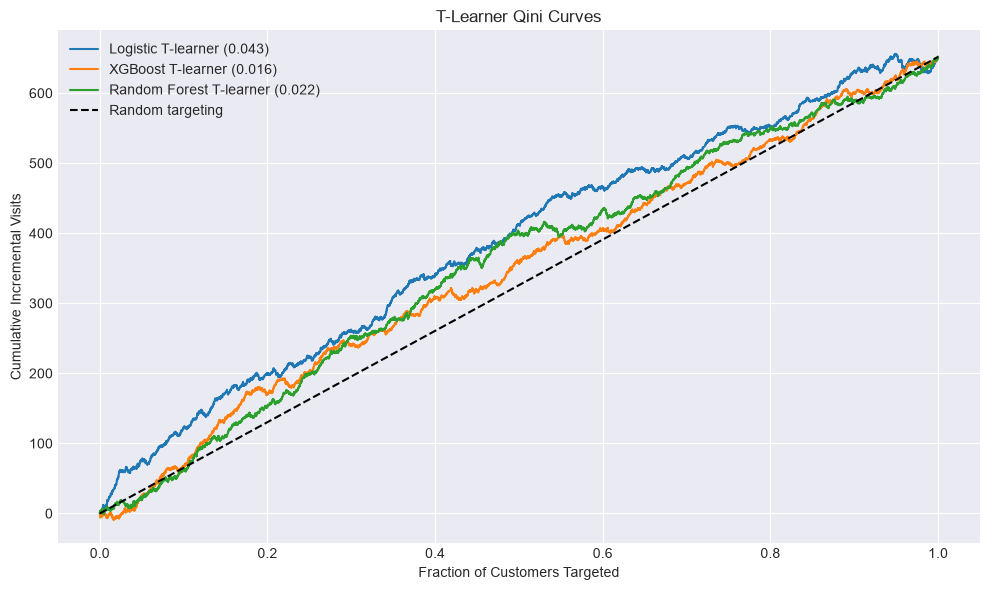

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(
    lgr_qini_x / number_of_test_customers,
    lgr_qini_y,
    label=f"Logistic T-learner ({lgr_qini_score:.3f})"
)

plt.plot(
    xgb_qini_x / number_of_test_customers,
    xgb_qini_y,
    label=f"XGBoost T-learner ({xgb_qini_score:.3f})"
)

plt.plot(
    rf_qini_x / number_of_test_customers,
    rf_qini_y,
    label=f"Random Forest T-learner ({rf_qini_score:.3f})"
)

plt.plot(
    random_qini_x / number_of_test_customers,
    random_qini_y,
    color="black",
    linestyle="--",
    label="Random targeting"
)

plt.xlabel("Fraction of Customers Targeted")
plt.ylabel("Cumulative Incremental Visits")
plt.title("T-Learner Qini Curves")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "t_learner_qini_curves.png",
    dpi=150
)

plt.show()

### Calculate uplift curves and AUUC

This cell summarizes how effectively each model concentrates cumulative uplift across all possible targeting depths.

In [28]:
lgr_uplift_x, lgr_uplift_y = uplift_curve(
    y_true=y_test,
    uplift=lgr_predicted_uplift,
    treatment=treatment_test
)

xgb_uplift_x, xgb_uplift_y = uplift_curve(
    y_true=y_test,
    uplift=xgb_predicted_uplift,
    treatment=treatment_test
)

rf_uplift_x, rf_uplift_y = uplift_curve(
    y_true=y_test,
    uplift=rf_predicted_uplift,
    treatment=treatment_test
)

lgr_auuc_score = uplift_auc_score(
    y_true=y_test,
    uplift=lgr_predicted_uplift,
    treatment=treatment_test
)

xgb_auuc_score = uplift_auc_score(
    y_true=y_test,
    uplift=xgb_predicted_uplift,
    treatment=treatment_test
)

rf_auuc_score = uplift_auc_score(
    y_true=y_test,
    uplift=rf_predicted_uplift,
    treatment=treatment_test
)

random_uplift_x = np.array([
    0,
    number_of_test_customers
])

random_uplift_y = np.array([
    0,
    lgr_uplift_y[-1]
])

print(f"Logistic AUUC score: {lgr_auuc_score:.4f}")
print(f"XGBoost AUUC score:  {xgb_auuc_score:.4f}")
print(f"Random Forest AUUC score: {rf_auuc_score:.4f}")
print("Random-targeting reference score: 0.0000")

Logistic AUUC score: 0.0261
XGBoost AUUC score:  0.0097
Random Forest AUUC score: 0.0130
Random-targeting reference score: 0.0000


/Users/chris/.venvs/comp653/lib/python3.12/site-packages/sklearn/utils/deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
/Users/chris/.venvs/comp653/lib/python3.12/site-packages/sklearn/utils/deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
/Users/chris/.venvs/comp653/lib/python3.12/site-packages/sklearn/utils/deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead

### Plot uplift curves

This chart compares the cumulative uplift produced by each model with the random-targeting baseline.

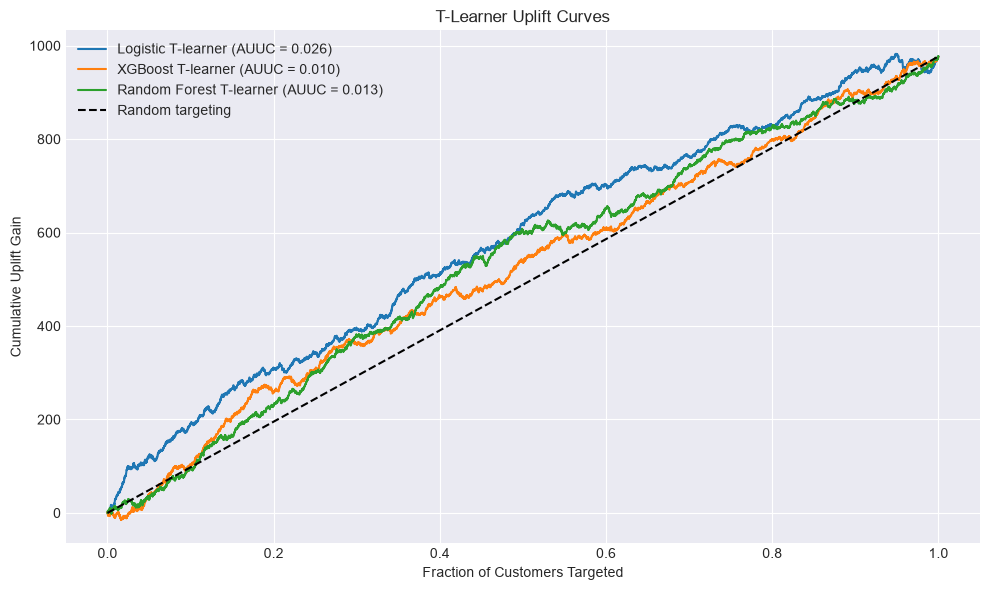

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(
    lgr_uplift_x / number_of_test_customers,
    lgr_uplift_y,
    label=f"Logistic T-learner (AUUC = {lgr_auuc_score:.3f})"
)

plt.plot(
    xgb_uplift_x / number_of_test_customers,
    xgb_uplift_y,
    label=f"XGBoost T-learner (AUUC = {xgb_auuc_score:.3f})"
)

plt.plot(
    rf_uplift_x / number_of_test_customers,
    rf_uplift_y,
    label=f"Random Forest T-learner (AUUC = {rf_auuc_score:.3f})"
)

plt.plot(
    random_uplift_x / number_of_test_customers,
    random_uplift_y,
    color="black",
    linestyle="--",
    label="Random targeting"
)

plt.xlabel("Fraction of Customers Targeted")
plt.ylabel("Cumulative Uplift Gain")
plt.title("T-Learner Uplift Curves")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "t_learner_uplift_curves.png",
    dpi=150
)

plt.show()

### Compare uplift-model performance

This cell summarizes the Qini and AUUC results, where higher positive values indicate better customer ranking than random targeting.

In [30]:
uplift_evaluation = pd.DataFrame({
    "Model": [
        "Logistic T-learner",
        "XGBoost T-learner",
        "Random Forest T-learner",
        "Random targeting",
    ],
    "Qini Score": [
        lgr_qini_score,
        xgb_qini_score,
        rf_qini_score,
        0.0,
    ],
    "AUUC Score": [
        lgr_auuc_score,
        xgb_auuc_score,
        rf_auuc_score,
        0.0,
    ],
})

display(uplift_evaluation)

,Model,Qini Score,AUUC Score
0,Logistic T-learner,0.043342,0.026051
1,XGBoost T-learner,0.016213,0.009721
2,Random Forest T-learner,0.021609,0.013021
3,Random targeting,0.000000,0.000000


### Combine decile results

This cell combines the logistic-regression and XGBoost decile tables into one model-comparison output.

In [31]:
lgr_decile_output = lgr_decile_results.copy()
lgr_decile_output.insert(
    0,
    "model",
    "Logistic T-learner"
)

xgb_decile_output = xgb_decile_results.copy()
xgb_decile_output.insert(
    0,
    "model",
    "XGBoost T-learner"
)

rf_decile_output = rf_decile_results.copy()
rf_decile_output.insert(
    0,
    "model",
    "Random Forest T-learner"
)

decile_comparison = pd.concat(
    [
        lgr_decile_output,
        xgb_decile_output,
        rf_decile_output,
    ],
    ignore_index=True
)

display(decile_comparison)

,model,decile,customers,mean_predicted_uplift,treated_customers,control_customers,treated_visit_rate,control_visit_rate,observed_uplift
0,Logistic T-learner,1,1600,0.096317,1024,576,0.245117,0.126736,0.118381
1,Logistic T-learner,2,1600,0.084653,1042,558,0.218810,0.143369,0.075441
2,Logistic T-learner,3,1600,0.079194,1112,488,0.174460,0.118852,0.055608
3,Logistic T-learner,4,1600,0.072374,1076,524,0.162639,0.085878,0.076762
4,Logistic T-learner,5,1600,0.066452,1079,521,0.164041,0.095969,0.068071
5,Logistic T-learner,6,1600,0.053762,1040,560,0.125000,0.076786,0.048214
6,Logistic T-learner,7,1600,0.046037,1081,519,0.139685,0.100193,0.039493
7,Logistic T-learner,8,1600,0.042286,1075,525,0.114419,0.072381,0.042038
8,Logistic T-learner,9,1600,0.037045,1077,523,0.139276,0.065010,0.074266
9,Logistic T-learner,10,1600,0.020285,1068,532,0.191948,0.172932,0.019015


### Save prediction and evaluation tables

This cell saves the customer predictions, factual metrics, uplift metrics, and decile results for later project analysis.

In [33]:
predictions_path = (
    PREDICTIONS_DIR
    / "t_learner_predictions.csv"
)

factual_results_path = (
    TABLES_DIR
    / "t_learner_factual_performance.csv"
)

uplift_results_path = (
    TABLES_DIR
    / "t_learner_uplift_performance.csv"
)

decile_results_path = (
    TABLES_DIR
    / "t_learner_decile_results.csv"
)

model_comparison_df.to_csv(
    predictions_path,
    index=False
)

factual_comparison.to_csv(
    factual_results_path,
    index=False
)

uplift_evaluation.to_csv(
    uplift_results_path,
    index=False
)

decile_comparison.to_csv(
    decile_results_path,
    index=False
)

print("Predictions saved to:", predictions_path)
print("Factual results saved to:", factual_results_path)
print("Uplift results saved to:", uplift_results_path)
print("Decile results saved to:", decile_results_path)

Predictions saved to: /Users/chris/Documents/GitHub/hillstrom-email-uplift-modeling/outputs/predictions/t_learner_predictions.csv
Factual results saved to: /Users/chris/Documents/GitHub/hillstrom-email-uplift-modeling/outputs/tables/t_learner_factual_performance.csv
Uplift results saved to: /Users/chris/Documents/GitHub/hillstrom-email-uplift-modeling/outputs/tables/t_learner_uplift_performance.csv
Decile results saved to: /Users/chris/Documents/GitHub/hillstrom-email-uplift-modeling/outputs/tables/t_learner_decile_results.csv


### Save model results and metadata

This cell saves the main model results in a structured JSON file for reproducibility.

In [34]:
results = {
    "metadata": {
        "model_type": "binary_treatment_t_learner",
        "outcome": PRIMARY_OUTCOME,
        "treatment_definition": "Any email versus no email",
        "test_size": int(len(y_test)),
        "observed_test_ate": float(observed_test_ate),
    },
    "lgr_t_learner": {
        "base_learner": "logistic_regression",
        "solver": "lbfgs",
        "average_predicted_uplift": float(
            lgr_average_predicted_uplift
        ),
        "minimum_predicted_uplift": float(
            lgr_minimum_predicted_uplift
        ),
        "maximum_predicted_uplift": float(
            lgr_maximum_predicted_uplift
        ),
        "treated_model_auc": float(lgr_treated_auc),
        "control_model_auc": float(lgr_control_auc),
        "treated_model_brier": float(lgr_treated_brier),
        "control_model_brier": float(lgr_control_brier),
        "qini_score": float(lgr_qini_score),
        "auuc_score": float(lgr_auuc_score),
    },
    "xgb_t_learner": {
        "base_learner": "xgboost",
        "parameters": xgb_parameters,
        "average_predicted_uplift": float(
            xgb_average_predicted_uplift
        ),
        "minimum_predicted_uplift": float(
            xgb_minimum_predicted_uplift
        ),
        "maximum_predicted_uplift": float(
            xgb_maximum_predicted_uplift
        ),
        "treated_model_auc": float(xgb_treated_auc),
        "control_model_auc": float(xgb_control_auc),
        "treated_model_brier": float(xgb_treated_brier),
        "control_model_brier": float(xgb_control_brier),
        "qini_score": float(xgb_qini_score),
        "auuc_score": float(xgb_auuc_score),
    },
    "rf_t_learner": {
        "base_learner": "random_forest",
        "parameters": rf_parameters,
        "average_predicted_uplift": float(
            rf_average_predicted_uplift
        ),
        "minimum_predicted_uplift": float(
            rf_minimum_predicted_uplift
        ),
        "maximum_predicted_uplift": float(
            rf_maximum_predicted_uplift
        ),
        "treated_model_auc": float(rf_treated_auc),
        "control_model_auc": float(rf_control_auc),
        "treated_model_brier": float(rf_treated_brier),
        "control_model_brier": float(rf_control_brier),
        "qini_score": float(rf_qini_score),
        "auuc_score": float(rf_auuc_score),
    },
}

results_path = (
    MODEL_RESULTS_DIR
    / "t_learner_results.json"
)

with open(results_path, "w") as file:
    json.dump(
        results,
        file,
        indent=4
    )

print("Model results saved to:", results_path)

Model results saved to: /Users/chris/Documents/GitHub/hillstrom-email-uplift-modeling/outputs/model_results/t_learner_results.json


### Summary

This notebook compared logistic-regression, XGBoost, and Random Forest T-learners using factual outcome-model performance, predicted-uplift distributions, uplift-by-decile results, Qini curves, and normalized AUUC scores. The preferred targeting model should demonstrate stronger observed lift in its highest-ranked deciles and higher positive Qini and AUUC scores than random targeting.